In [ ]:
import pandas as pd

file_path = '/content/data_pdrb_dummy.csv'

df_raw = pd.read_csv(file_path, skiprows=2)

columns = ['Provinsi', '2019', '2020', '2021', '2022', '2023', '2024']
df_raw.columns = columns

df_clean = df_raw[df_raw['Provinsi'].notna()].copy()

for year in columns[1:]:
    df_clean[year] = pd.to_numeric(df_clean[year], errors='coerce')

df_long = df_clean.melt(id_vars=['Provinsi'], var_name='Tahun', value_name='PDRB_ADHK')

print(df_long.head())

df_long.to_csv('/content/pdrb_adhk_panel.csv', index=False)

         Provinsi Tahun  PDRB_ADHK
0            Aceh  2019  132069.62
1  Sumatera Utara  2019  539513.85
2  Sumatera Barat  2019  172205.57
3            Riau  2019  495607.05
4           Jambi  2019  149111.09


In [ ]:
file_pdb_nasional = '/content/data_pdb_nasional_dummy.csv'

df_pdb_raw = pd.read_csv(file_pdb_nasional, skiprows=2)

columns_pdb = ['Sektor', '2019', '2020', '2021', '2022', '2023', '2024']
df_pdb_raw.columns = columns_pdb

df_pdb_clean = df_pdb_raw[df_pdb_raw['Sektor'].notna()].copy()

for year in columns_pdb[1:]:
    df_pdb_clean[year] = pd.to_numeric(df_pdb_clean[year], errors='coerce')

df_pdb_long = df_pdb_clean.melt(id_vars=['Sektor'], var_name='Tahun', value_name='PDB_ADHK_Sektor')

print(df_pdb_long.head())

df_pdb_long.to_csv('/content/pdb_nasional_adhk_sektor_panel.csv', index=False)

                                              Sektor Tahun  PDB_ADHK_Sektor
0  APertanian, Kehutanan, dan Perikanan\nAgricult...  2019        1354399.1
1  1Pertanian, Peternakan, Perburuan, dan Jasa Pe...  2019        1038902.9
2                       a. Tanaman Pangan/Food Crops  2019         292883.0
3        b. Tanaman Hortikultura/Horticultural Crops  2019         153157.8
4             c. Tanaman Perkebunan/Plantation Crops  2019         405147.5


In [ ]:
total_pdb_nasional = df_pdb_long.groupby('Tahun')['PDB_ADHK_Sektor'].sum().reset_index()
total_pdb_nasional.rename(columns={'PDB_ADHK_Sektor': 'Total_PDB_Nasional'}, inplace=True)

total_pdb_nasional['Growth_Nasional'] = total_pdb_nasional['Total_PDB_Nasional'].pct_change()

df_pdb_growth = df_pdb_long.copy()
df_pdb_growth = df_pdb_growth.merge(total_pdb_nasional, on='Tahun')

df_pdb_growth['PDB_Sebelumnya'] = df_pdb_growth.groupby('Sektor')['PDB_ADHK_Sektor'].shift(1)
df_pdb_growth['Growth_Sektor'] = (df_pdb_growth['PDB_ADHK_Sektor'] - df_pdb_growth['PDB_Sebelumnya']) / df_pdb_growth['PDB_Sebelumnya']

df_pdb_growth.to_csv('/content/pertumbuhan_pdb_sektoral_dan_nasional.csv', index=False)

In [ ]:
df_growth = df_long.copy()
df_growth['PDRB_t-1'] = df_growth.groupby('Provinsi')['PDRB_ADHK'].shift(1)

df_growth['Growth_Provinsi'] = (df_growth['PDRB_ADHK'] - df_growth['PDRB_t-1']) / df_growth['PDRB_t-1']

df_growth.to_csv('/content/pertumbuhan_pdrb_provinsi.csv', index=False)

In [ ]:
df_growth = df_growth.merge(total_pdb_nasional[['Tahun', 'Growth_Nasional']], on='Tahun', how='left')

df_growth['NS'] = df_growth['PDRB_t-1'] * df_growth['Growth_Nasional']

df_growth['RS'] = df_growth['PDRB_t-1'] * (df_growth['Growth_Provinsi'] - df_growth['Growth_Nasional'])

df_growth.to_csv('/content/hasil_shift_share_NS_RS.csv', index=False)

print(df_growth[['Provinsi', 'Tahun', 'PDRB_ADHK', 'Growth_Provinsi', 'Growth_Nasional', 'NS', 'RS']].head())

         Provinsi Tahun  PDRB_ADHK  Growth_Provinsi  Growth_Nasional  NS  RS
0            Aceh  2019  132069.62              NaN              NaN NaN NaN
1  Sumatera Utara  2019  539513.85              NaN              NaN NaN NaN
2  Sumatera Barat  2019  172205.57              NaN              NaN NaN NaN
3            Riau  2019  495607.05              NaN              NaN NaN NaN
4           Jambi  2019  149111.09              NaN              NaN NaN NaN


In [ ]:
df_valid = df_growth[df_growth['Tahun'] != '2019']
print(df_valid[['Provinsi', 'Tahun', 'Growth_Provinsi', 'Growth_Nasional', 'NS', 'RS']].head())

          Provinsi Tahun  Growth_Provinsi  Growth_Nasional            NS  \
38            Aceh  2020        -0.003700        -0.019728  -2605.472744   
39  Sumatera Utara  2020        -0.010690        -0.019728 -10643.542635   
40  Sumatera Barat  2020        -0.016137        -0.019728  -3397.275763   
41            Riau  2020        -0.011322        -0.019728  -9777.348194   
42           Jambi  2020        -0.005076        -0.019728  -2941.667288   

             RS  
38  2116.822744  
39  4876.052635  
40   618.315763  
41  4166.048194  
42  2184.827288  


In [ ]:
tahun_target = '2020'

growth_sektor = df_pdb_growth[df_pdb_growth['Tahun'] == tahun_target]['Growth_Sektor'].mean()

growth_nasional = total_pdb_nasional[total_pdb_nasional['Tahun'] == tahun_target]['Growth_Nasional'].values[0]

df_target = df_growth[df_growth['Tahun'] == tahun_target].copy()

df_target['IM'] = df_target['PDRB_t-1'] * (growth_sektor - growth_nasional)

print(df_target[['Provinsi', 'NS', 'IM', 'RS']].sort_values(by='IM', ascending=False))

                     Provinsi            NS            IM            RS
75           Papua Pegunungan     -0.000000     -0.000000           NaN
71           Papua Barat Daya     -0.000000     -0.000000           NaN
73              Papua Selatan     -0.000000     -0.000000           NaN
74               Papua Tengah     -0.000000     -0.000000           NaN
69               Maluku Utara   -524.717127   -573.280180   1958.607127
66                  Gorontalo   -560.867154   -612.775926    556.277154
68                     Maluku   -612.544321   -669.235861    328.984321
67             Sulawesi Barat   -647.943500   -707.911267   -121.846500
44                   Bengkulu   -914.304189   -998.923883    907.284189
46  Kepulauan Bangka Belitung  -1064.167143  -1162.656791   -171.792857
61           Kalimantan Utara  -1211.651687  -1323.791165    540.071687
70                Papua Barat  -1224.607673  -1337.946239    754.217673
56        Nusa Tenggara Timur  -1368.908310  -1495.602034    789

In [ ]:
df_target[['Provinsi', 'Tahun', 'PDRB_ADHK', 'PDRB_t-1', 'Growth_Provinsi', 'Growth_Nasional', 'NS', 'IM', 'RS']] \
    .sort_values(by='RS', ascending=False) \
    .to_excel('/content/hasil_shift_share_NS_IM_RS_2020.xlsx', index=False)

print("Done.")

✅ Hasil lengkap NS, IM, RS tahun 2020 sudah disimpan dalam Excel.


<ipython-input-33-9149c4f45784>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rs, y='Provinsi', x='RS', palette='viridis')


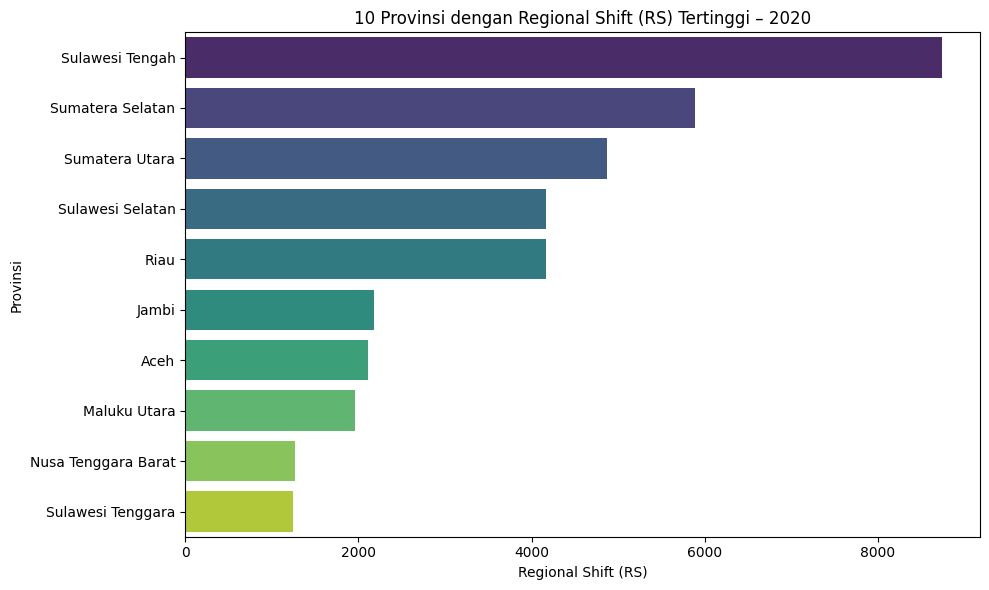

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_rs = df_target.sort_values(by='RS', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_rs, y='Provinsi', x='RS', palette='viridis')
plt.title('10 Provinsi dengan Regional Shift (RS) Tertinggi – 2020')
plt.xlabel('Regional Shift (RS)')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

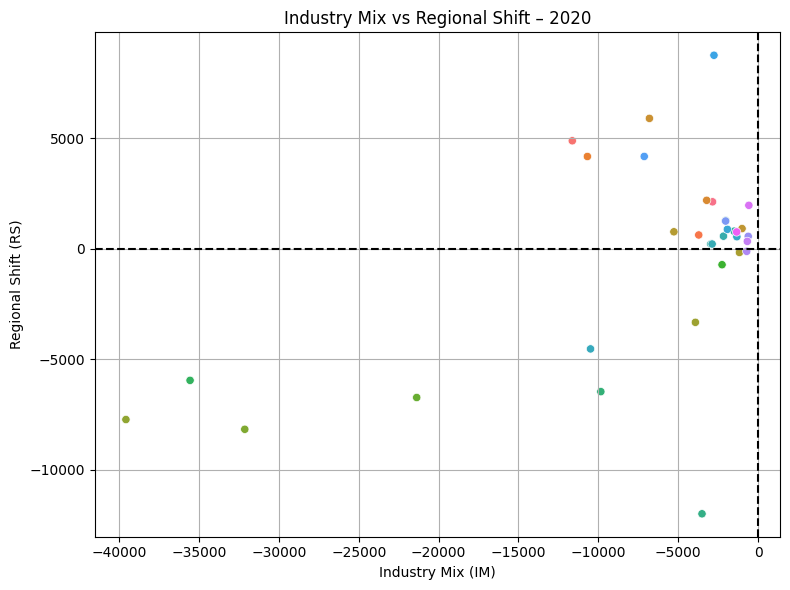

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_target, x='IM', y='RS', hue='Provinsi', legend=False)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title('Industry Mix vs Regional Shift – 2020')
plt.xlabel('Industry Mix (IM)')
plt.ylabel('Regional Shift (RS)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_adhk = pd.read_csv('/content/data_pdrb_dummy.csv', skiprows=2)
df_adhk.columns = ['Provinsi', '2019', '2020', '2021', '2022', '2023', '2024']
df_adhk = df_adhk[df_adhk['Provinsi'].notna()].copy()
for y in ['2019','2020','2021','2022','2023','2024']:
    df_adhk[y] = pd.to_numeric(df_adhk[y], errors='coerce')
df_long = df_adhk.melt(id_vars=['Provinsi'], var_name='Tahun', value_name='PDRB_ADHK')

df_pdb = pd.read_csv('/content/data_pdb_nasional_dummy.csv', skiprows=2)
df_pdb.columns = ['Sektor', '2019', '2020', '2021', '2022', '2023', '2024']
df_pdb = df_pdb[df_pdb['Sektor'].notna()].copy()
for y in ['2019','2020','2021','2022','2023','2024']:
    df_pdb[y] = pd.to_numeric(df_pdb[y], errors='coerce')
df_pdb_long = df_pdb.melt(id_vars=['Sektor'], var_name='Tahun', value_name='PDB_ADHK_Sektor')

total_pdb = df_pdb_long.groupby('Tahun')['PDB_ADHK_Sektor'].sum().reset_index()
total_pdb['Growth_Nasional'] = total_pdb['PDB_ADHK_Sektor'].pct_change()
rata_growth_sektor = df_pdb_long.groupby('Tahun')['PDB_ADHK_Sektor'].pct_change().groupby(df_pdb_long['Tahun']).mean().reset_index()
rata_growth_sektor.columns = ['Tahun', 'Avg_Growth_Sektor']

df_growth = df_long.copy()
df_growth['PDRB_t-1'] = df_growth.groupby('Provinsi')['PDRB_ADHK'].shift(1)
df_growth['Growth_Provinsi'] = df_growth.groupby('Provinsi')['PDRB_ADHK'].pct_change()
df_growth = df_growth.merge(total_pdb, on='Tahun', how='left')
df_growth = df_growth.merge(rata_growth_sektor, on='Tahun', how='left')

df_growth['NS'] = df_growth['PDRB_t-1'] * df_growth['Growth_Nasional']
df_growth['IM'] = df_growth['PDRB_t-1'] * (df_growth['Avg_Growth_Sektor'] - df_growth['Growth_Nasional'])
df_growth['RS'] = df_growth['PDRB_t-1'] * (df_growth['Growth_Provinsi'] - df_growth['Growth_Nasional'])

df_growth.to_csv('/content/shift_share_full_2020_2024.csv', index=False)
print(df_growth[['Provinsi', 'Tahun', 'NS', 'IM', 'RS']].dropna().head(10))

✅ Hasil lengkap Shift-Share tersimpan sebagai 'shift_share_full_2020_2024.csv'
                     Provinsi Tahun            NS            IM           RS
38                       Aceh  2020  -2605.472744  7.623814e+05  2116.822744
39             Sumatera Utara  2020 -10643.542635  3.114383e+06  4876.052635
40             Sumatera Barat  2020  -3397.275763  9.940691e+05   618.315763
41                       Riau  2020  -9777.348194  2.860928e+06  4166.048194
42                      Jambi  2020  -2941.667288  8.607546e+05  2184.827288
43           Sumatera Selatan  2020  -6223.496425  1.821043e+06  5887.966425
44                   Bengkulu  2020   -914.304189  2.675325e+05   907.284189
45                    Lampung  2020  -4821.101370  1.410691e+06   762.381370
46  Kepulauan Bangka Belitung  2020  -1064.167143  3.113835e+05  -171.792857
47             Kepulauan Riau  2020  -3588.087192  1.049902e+06 -3330.372808


<ipython-input-35-98760d3b0770>:31: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_growth['Growth_Provinsi'] = df_growth.groupby('Provinsi')['PDRB_ADHK'].pct_change()


In [ ]:
!pip install openpyxl

df_growth.dropna().to_excel('/content/hasil_shift_share_NS_IM_RS_2020_2024.xlsx', index=False)

print("File saved.")

📁 Hasil Shift-Share 2020–2024 disimpan sebagai 'hasil_shift_share_NS_IM_RS_2020_2024.xlsx'


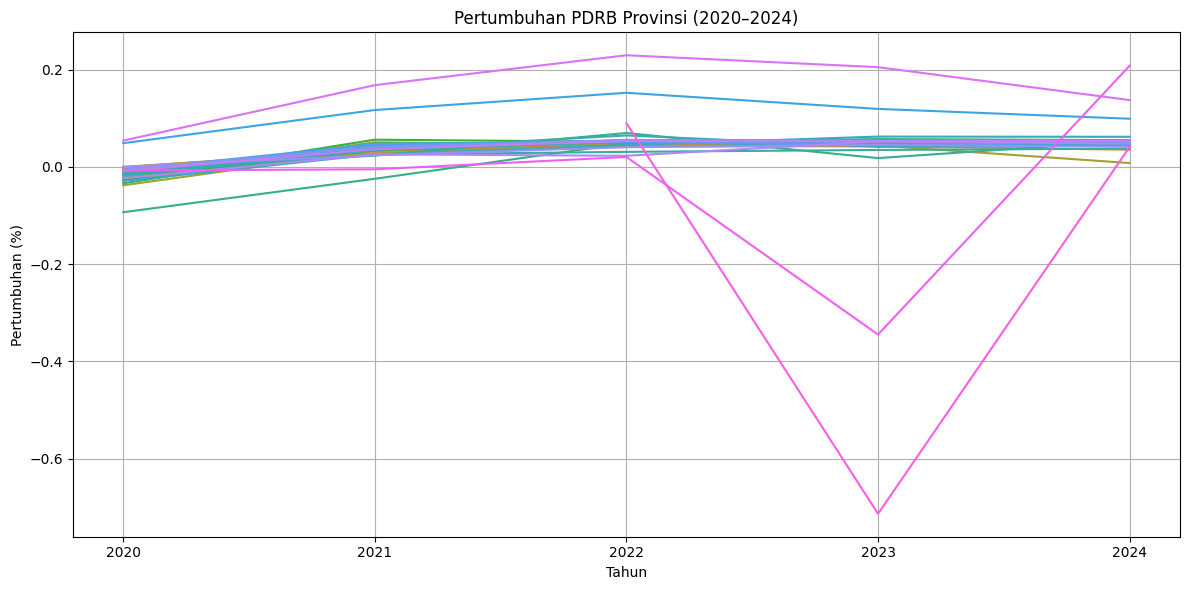

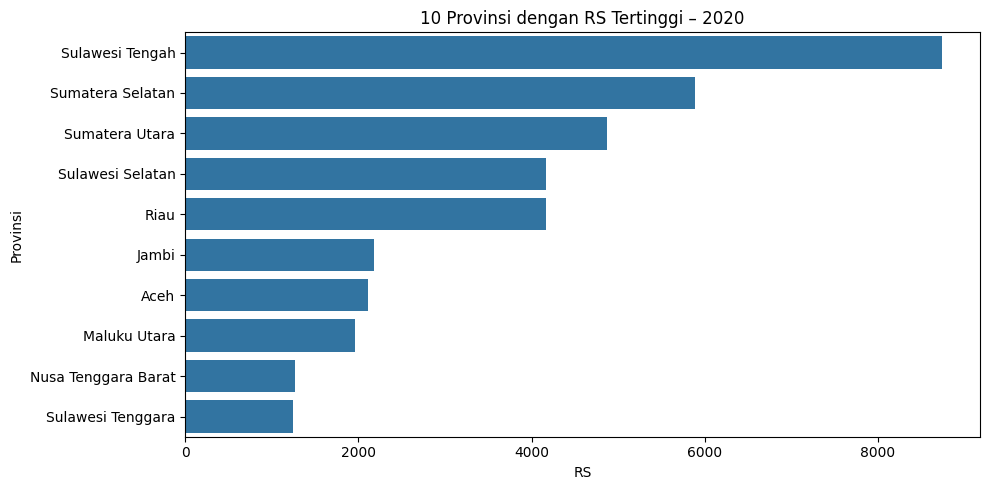

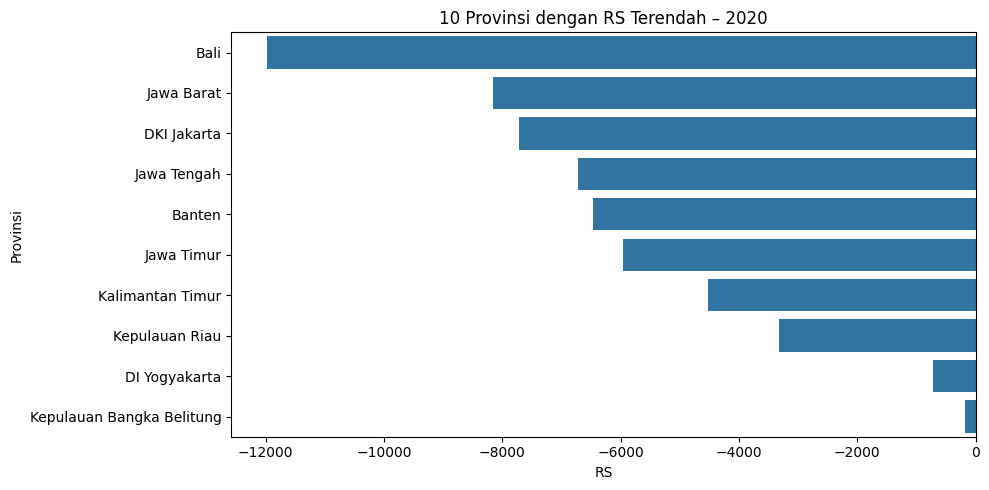

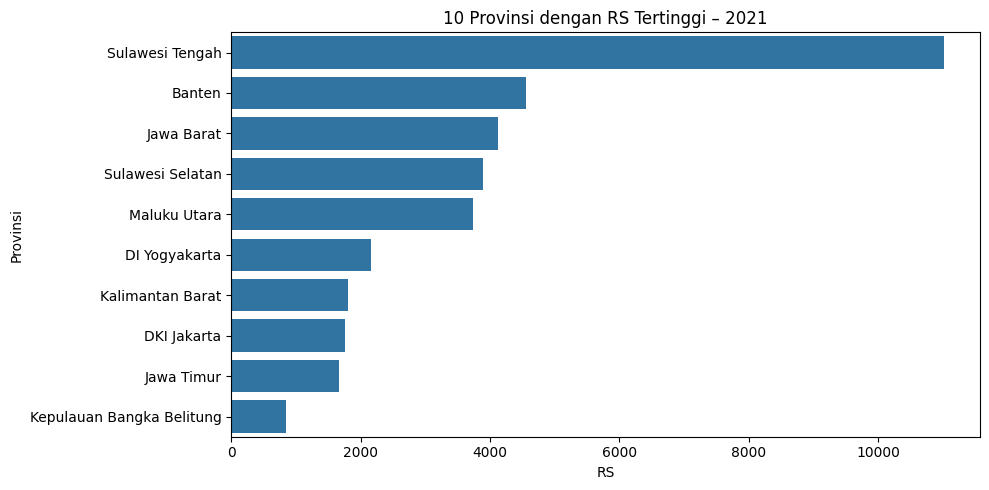

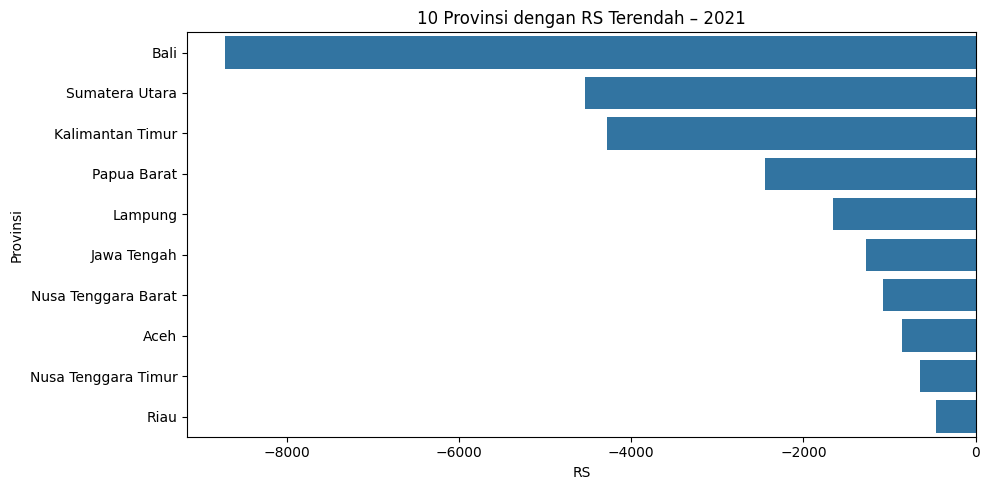

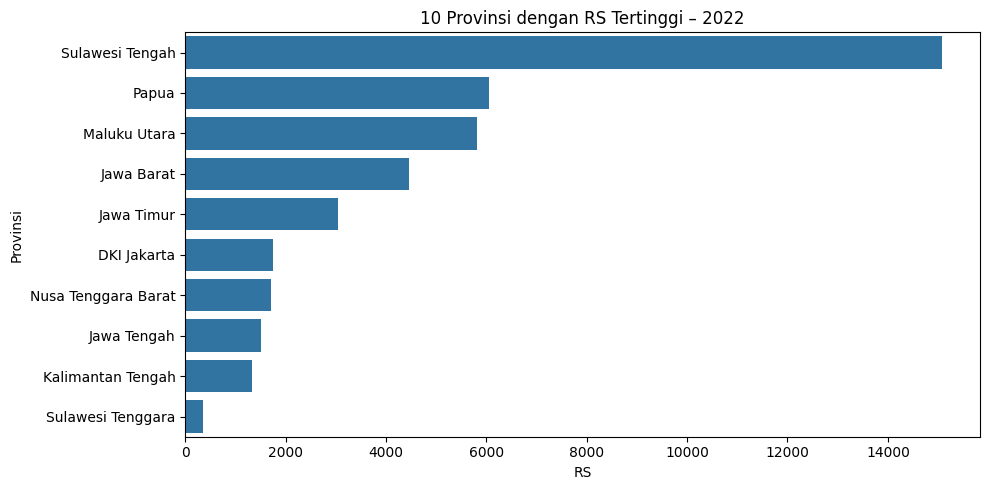

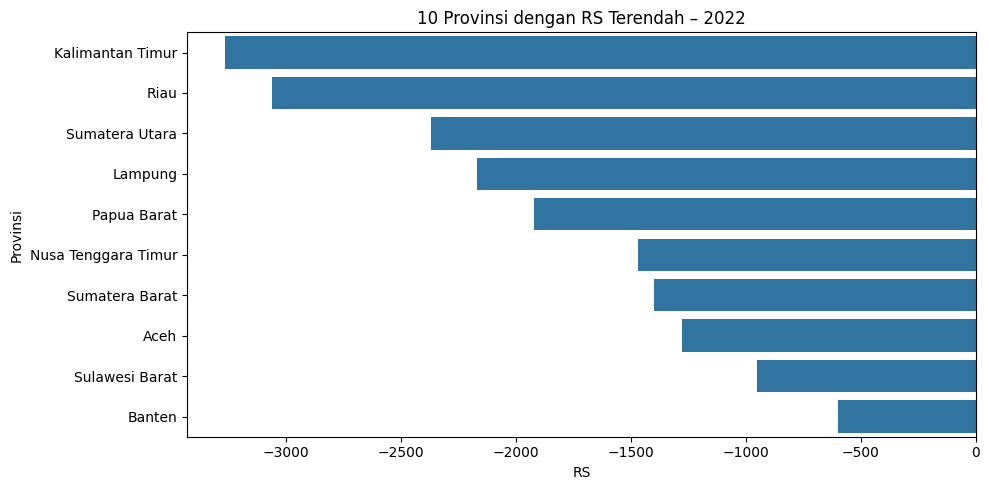

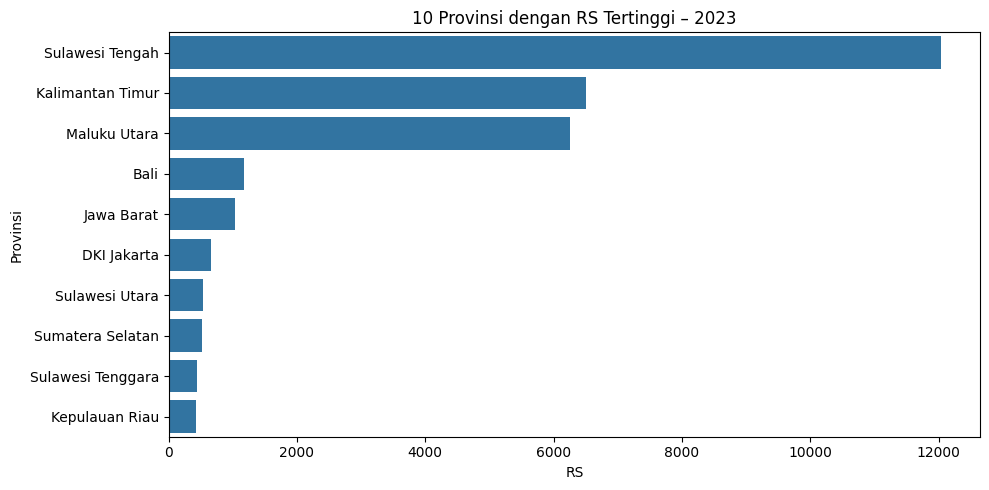

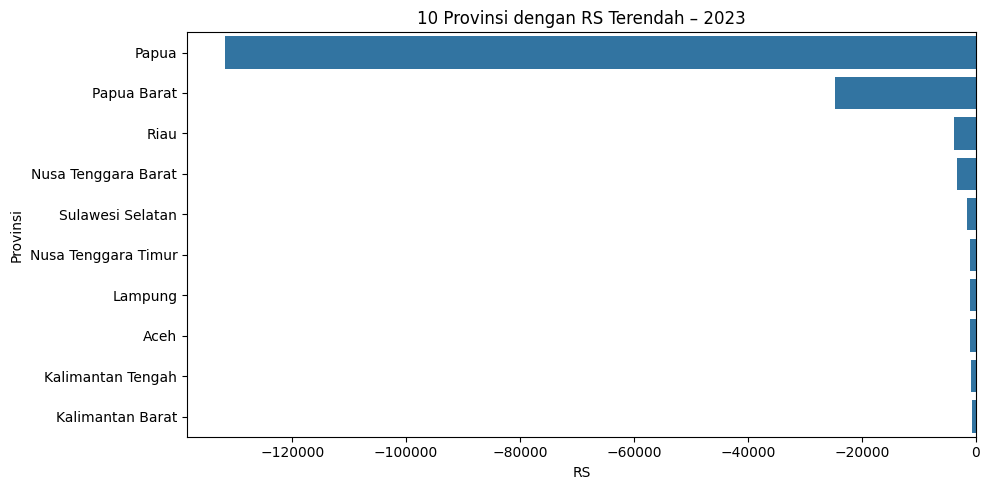

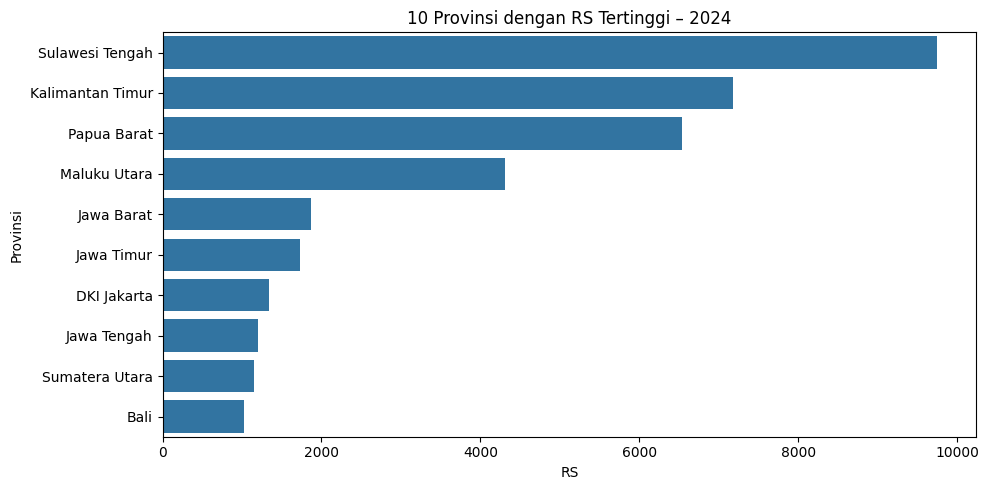

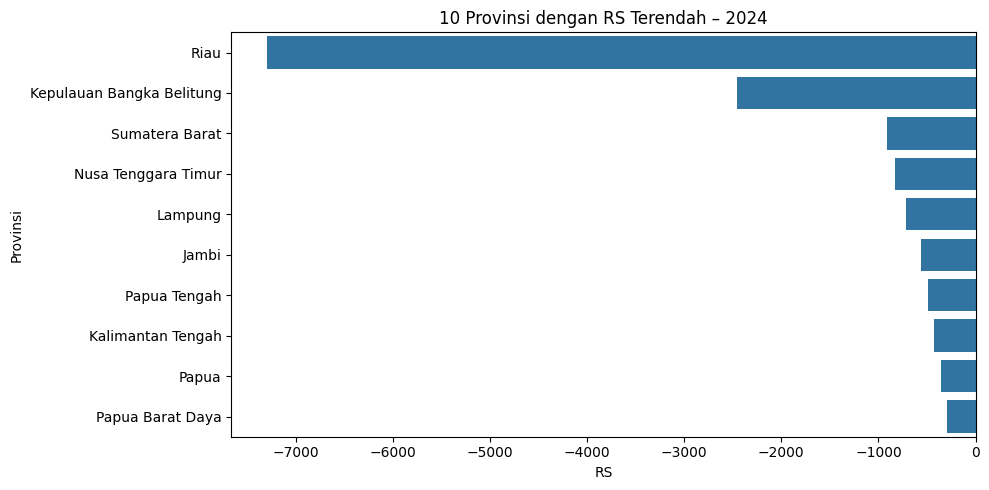

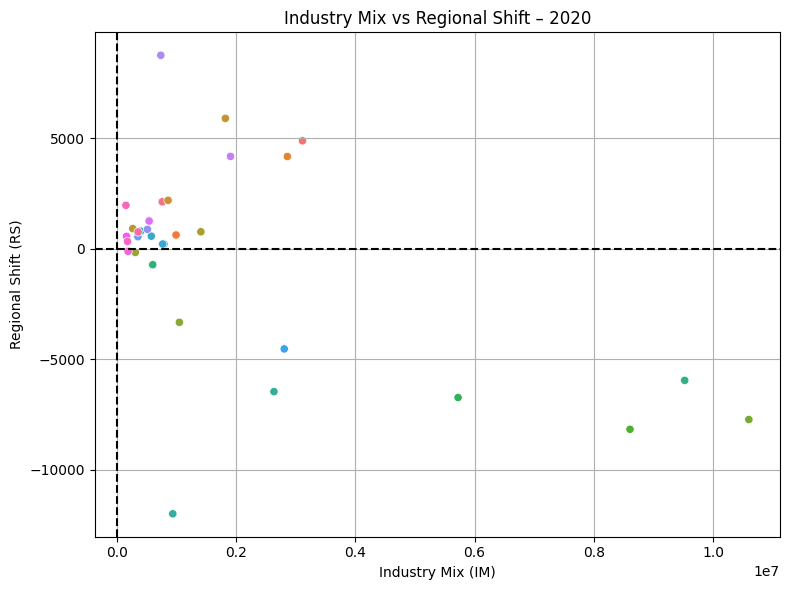

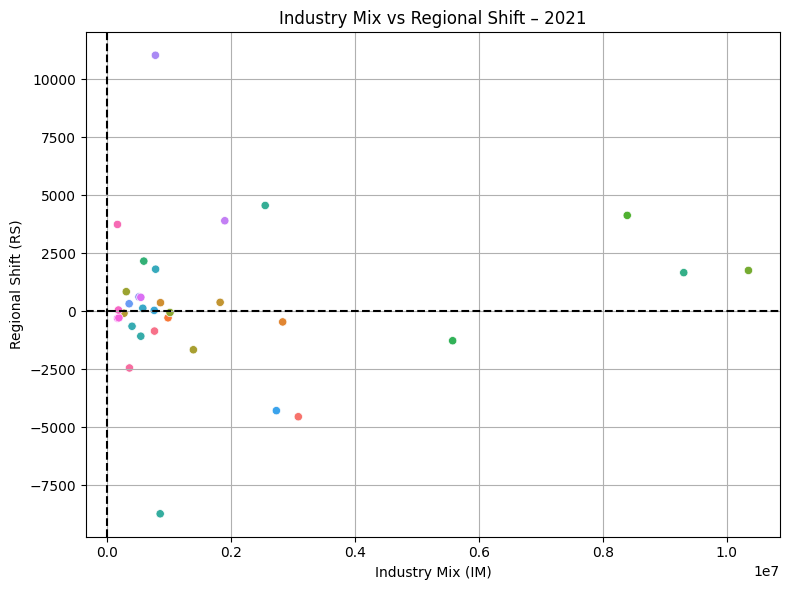

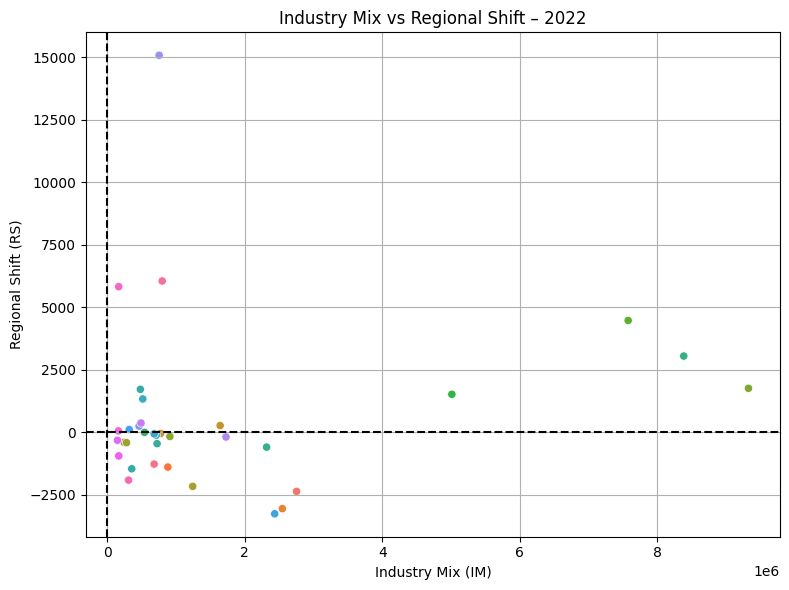

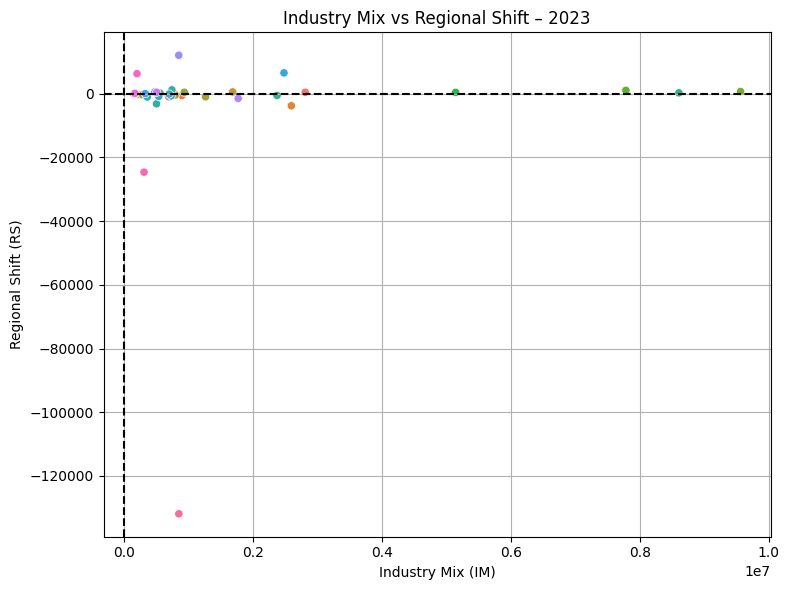

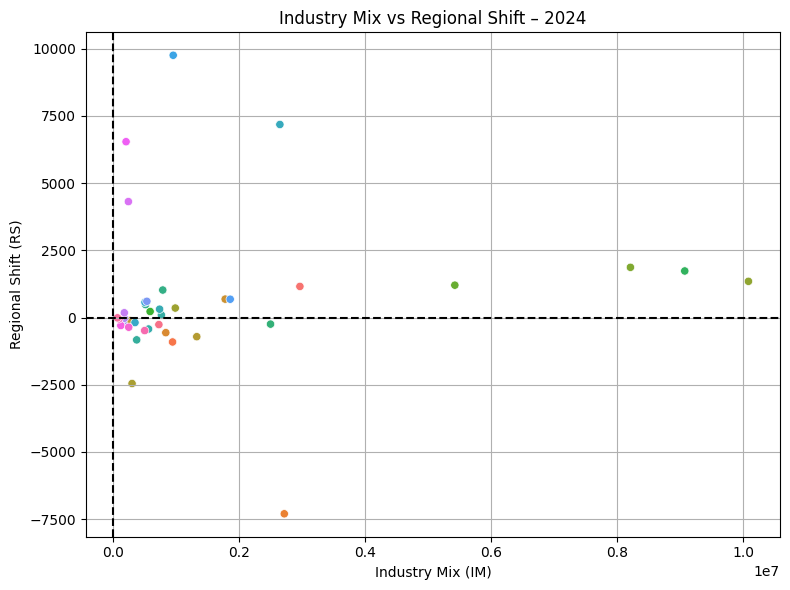

Zonasi,Kompetitif & Tumbuh Cepat,Tumbuh karena Struktur
Tahun,,
2020,22,11
2021,18,15
2022,14,20
2023,17,17
2024,20,18


✅ Zonasi wilayah berdasarkan IM & RS telah disimpan sebagai Excel.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/hasil_shift_share_NS_IM_RS_2020_2024.xlsx')

df['Tahun'] = df['Tahun'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Tahun', y='Growth_Provinsi', hue='Provinsi', legend=False)
plt.title('Pertumbuhan PDRB Provinsi (2020–2024)')
plt.ylabel('Pertumbuhan (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

for year in df['Tahun'].unique():
    df_year = df[df['Tahun'] == year].copy()
    top_rs = df_year.sort_values(by='RS', ascending=False).head(10)
    low_rs = df_year.sort_values(by='RS').head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_rs, x='RS', y='Provinsi')
    plt.title(f'10 Provinsi dengan RS Tertinggi – {year}')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=low_rs, x='RS', y='Provinsi')
    plt.title(f'10 Provinsi dengan RS Terendah – {year}')
    plt.tight_layout()
    plt.show()

for year in df['Tahun'].unique():
    df_year = df[df['Tahun'] == year]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_year, x='IM', y='RS', hue='Provinsi', legend=False)
    plt.axhline(0, color='black', linestyle='--')
    plt.axvline(0, color='black', linestyle='--')
    plt.title(f'Industry Mix vs Regional Shift – {year}')
    plt.xlabel('Industry Mix (IM)')
    plt.ylabel('Regional Shift (RS)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def kuadran(im, rs):
    if rs > 0 and im > 0:
        return 'Kompetitif & Tumbuh Cepat'
    elif rs < 0 and im < 0:
        return 'Tertinggal Struktural'
    elif rs < 0 and im > 0:
        return 'Tumbuh karena Struktur'
    elif rs > 0 and im < 0:
        return 'Unggul karena Daya Saing Lokal'
    else:
        return 'Tidak Terklasifikasi'

df['Zonasi'] = df.apply(lambda row: kuadran(row['IM'], row['RS']), axis=1)

zonasi_summary = df.groupby(['Tahun', 'Zonasi'])['Provinsi'].count().unstack().fillna(0)
display(zonasi_summary)

df[['Provinsi', 'Tahun', 'IM', 'RS', 'Zonasi']].to_excel('/content/zonasi_shift_share_2020_2024.xlsx', index=False)
print("Success.")

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=zonasi_summary)

https://docs.google.com/spreadsheets/d/1QFHA6S9iF_5FTZ7ncGCuw8v-WThtbqwceuGGhdP-t34/edit#gid=0
